# Peptide Biophysical Property Calculator
### FASTA → Biophysical Features → CSV (Google Colab Ready)

This notebook computes a comprehensive set of **biophysical properties** for each peptide/protein sequence in a FASTA file — useful for antimicrobial peptide (AMP), cell-penetrating peptide (CPP), and general therapeutic peptide characterization.

**Pipeline:**
1. Install dependencies
2. Upload / load a FASTA file
3. Parse sequences
4. Compute physicochemical, compositional, hydrophobicity, structural, and complexity features
5. Assemble a single results table: `Sequence, MW, Feature1, Feature2, ...`
6. Export to CSV (and download automatically in Colab)

> Run the cells in order (Runtime → Run all).


## Step 1 — Install Required Libraries

In [1]:
!pip -q install biopython modlamp peptides pandas
print("Libraries installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 653.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.7/176.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.0 MB/s eta 0:00:00
Libraries installed.


## Step 2 — Upload Your FASTA File

Run the cell below and select your `.fasta` / `.fa` file when prompted.
(If you're not on Colab, just set `FASTA_PATH` manually and skip the upload widget.)

In [11]:
import os

FASTA_PATH = None  # will be set automatically after upload

try:
    from google.colab import files
    uploaded = files.upload()
    FASTA_PATH = list(uploaded.keys())[0]
    print(f"Uploaded file: {FASTA_PATH}")
except ImportError:
    # Not running in Colab -- set the path manually here
    FASTA_PATH = "peptides.fasta"
    print(f"Not running in Colab. Using manual path: {FASTA_PATH}")

assert FASTA_PATH is not None and os.path.exists(FASTA_PATH), \
    "FASTA file not found. Upload a file or set FASTA_PATH manually."


Saving amp-combined-dataset-1.csv to amp-combined-dataset-1.csv
Uploaded file: amp-combined-dataset-1.csv


In [14]:
import pandas as pd
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Read the uploaded CSV
df = pd.read_csv(FASTA_PATH)

print(df.head())
print(df.columns)

# Create SeqRecord objects
records = [
    SeqRecord(
        Seq(str(seq).strip().upper()),
        id=f"Pep_{i+1}",
        description=""
    )
    for i, seq in enumerate(df["Sequence"])
]

print(f"Loaded {len(records)} sequences.")

                                            Sequence Class
0  MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...   AMP
1  MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...   AMP
2  MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...   AMP
3  VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...   AMP
4  MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...   AMP
Index(['Sequence', 'Class'], dtype='object')
Loaded 156 sequences.


## Step 3 — Parse the FASTA File

Some FASTA files include comment lines (starting with `;` or `#`) before the
first `>` header, which BioPython's strict `fasta` parser rejects. The cell
below cleans those out automatically, then parses normally — no manual
file editing required.

In [16]:
import pandas as pd
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Read uploaded CSV
df = pd.read_csv(FASTA_PATH)

# Check that the Sequence column exists
assert "Sequence" in df.columns, "CSV must contain a column named 'Sequence'"

# Remove empty rows
df = df.dropna(subset=["Sequence"])

# Clean sequences
df["Sequence"] = (
    df["Sequence"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Create SeqRecord objects (optional)
records = [
    SeqRecord(
        Seq(seq),
        id=f"Pep_{i+1}",
        description=""
    )
    for i, seq in enumerate(df["Sequence"])
]

print(f"Loaded {len(records)} sequences.\n")

for r in records[:5]:
    print(r.id, len(r.seq), r.seq[:20], "...")

Loaded 156 sequences.

Pep_1 84 MSQNVLTVYGADWCRDCLRT ...
Pep_2 79 MAKAELRKPKPKSNPLKAAK ...
Pep_3 99 MAEKKTEKNGAPMGPGTSSI ...
Pep_4 79 VNFALDGRNYEIDLSKEHAA ...
Pep_5 88 MTDVPFEDREDERELETDLL ...


## Step 4 — Helper Functions

Custom functions for properties not directly provided by BioPython / `peptides`:
Shannon entropy, hydrophobic residue ratio, and residue-class counts.

In [17]:
import math

HYDROPHOBIC_RESIDUES = set("AILMFWVY")
POLAR_RESIDUES       = set("STNQCY")
NONPOLAR_RESIDUES    = set("AVLIMFWPG")
ACIDIC_RESIDUES      = set("DE")
BASIC_RESIDUES       = set("KRH")
TINY_RESIDUES        = set("AGCS")
SMALL_RESIDUES       = set("AGCSPNDT")
SULFUR_RESIDUES      = set("CM")


def shannon_entropy(sequence: str) -> float:
    """Shannon entropy (bits) of the amino acid distribution in a sequence."""
    freq = {}
    for aa in sequence:
        freq[aa] = freq.get(aa, 0) + 1
    n = len(sequence)
    h = 0.0
    for f in freq.values():
        p = f / n
        h -= p * math.log2(p)
    return h


def residue_ratio(sequence: str, residue_set: set) -> float:
    """Percentage of residues in `sequence` that belong to `residue_set`."""
    if len(sequence) == 0:
        return 0.0
    return sum(aa in residue_set for aa in sequence) / len(sequence) * 100


def residue_count(sequence: str, residue_set: set) -> int:
    """Raw count of residues in `sequence` that belong to `residue_set`."""
    return sum(aa in residue_set for aa in sequence)


## Step 5 — Compute Biophysical Features

For every sequence we compute:

| Category | Features |
|---|---|
| Basic physicochemical | Molecular weight, length, pI, net charge |
| Hydrophobicity | GRAVY, hydrophobic moment, hydrophobic ratio |
| Structural | Instability index, aliphatic index, helix/turn/sheet fraction |
| Membrane interaction | Boman index |
| Composition | Aromaticity, positive/negative/polar/nonpolar/tiny/small residue % |
| Complexity | Shannon entropy |
| Specific residues | Proline, Glycine, Cysteine content (%) |


In [18]:
import pandas as pd
import peptides
from Bio.SeqUtils.ProtParam import ProteinAnalysis

results = []

for record in records:
    seq = str(record.seq).upper().replace("*", "")  # strip stop codons if present
    if len(seq) == 0:
        continue

    try:
        X = ProteinAnalysis(seq)
        pep = peptides.Peptide(seq)
        helix, turn, sheet = X.secondary_structure_fraction()

        row = {
            "ID": record.id,
            "Sequence": seq,
            "MW": round(X.molecular_weight(), 3),
            "Length": len(seq),
            "pI": round(X.isoelectric_point(), 3),
            "Charge_pH7": round(pep.charge(pH=7.0), 3),
            "GRAVY": round(X.gravy(), 4),
            "Aromaticity": round(X.aromaticity(), 4),
            "InstabilityIndex": round(X.instability_index(), 3),
            "AliphaticIndex": round(pep.aliphatic_index(), 3),
            "BomanIndex": round(pep.boman(), 3),
            "HydrophobicMoment": round(pep.hydrophobic_moment(), 4),
            "HydrophobicRatio": round(residue_ratio(seq, HYDROPHOBIC_RESIDUES), 2),
            "HelixFraction": round(helix, 4),
            "TurnFraction": round(turn, 4),
            "SheetFraction": round(sheet, 4),
            "ShannonEntropy": round(shannon_entropy(seq), 4),
            "PositiveResidues_pct": round(residue_ratio(seq, BASIC_RESIDUES), 2),
            "NegativeResidues_pct": round(residue_ratio(seq, ACIDIC_RESIDUES), 2),
            "PolarResidues_pct": round(residue_ratio(seq, POLAR_RESIDUES), 2),
            "NonpolarResidues_pct": round(residue_ratio(seq, NONPOLAR_RESIDUES), 2),
            "TinyResidues_pct": round(residue_ratio(seq, TINY_RESIDUES), 2),
            "SmallResidues_pct": round(residue_ratio(seq, SMALL_RESIDUES), 2),
            "SulfurResidues_pct": round(residue_ratio(seq, SULFUR_RESIDUES), 2),
            "Proline_pct": round(residue_ratio(seq, {"P"}), 2),
            "Glycine_pct": round(residue_ratio(seq, {"G"}), 2),
            "Cysteine_pct": round(residue_ratio(seq, {"C"}), 2),
        }
        results.append(row)

    except Exception as e:
        print(f"Skipped {record.id}: {e}")

print(f"Computed features for {len(results)} / {len(records)} sequences.")


Computed features for 156 / 156 sequences.


## Step 6 — Assemble & Order the Results Table

Final column order:
`ID, Sequence, MW, Feature1, Feature2, Feature3, ...`

In [19]:
df = pd.DataFrame(results)

# Enforce the requested column order: ID, Sequence, MW, then all remaining features
ordered_cols = ["ID", "Sequence", "MW"] + [c for c in df.columns if c not in ("ID", "Sequence", "MW")]
df = df[ordered_cols]

print(f"Final table shape: {df.shape[0]} sequences x {df.shape[1]} columns")
df.head()


Final table shape: 156 sequences x 27 columns


,ID,Sequence,MW,Length,pI,Charge_pH7,GRAVY,Aromaticity,InstabilityIndex,AliphaticIndex,...,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,NonpolarResidues_pct,TinyResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,Pep_1,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,9218.249,84,4.469,-6.026,-0.2357,0.0595,36.588,94.048,...,10.71,16.67,22.62,50.00,22.62,47.62,3.57,4.76,5.95,2.38
1,Pep_2,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,8756.247,79,10.853,13.001,-0.5481,0.0380,23.335,91.519,...,25.32,8.86,15.19,50.63,24.05,39.24,1.27,5.06,6.33,0.00
2,Pep_3,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,10934.853,99,5.019,-4.883,-1.1606,0.0303,43.276,55.455,...,19.19,23.23,16.16,41.41,29.29,47.47,3.03,3.03,9.09,0.00
3,Pep_4,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,9084.225,79,9.845,6.190,-0.8975,0.0886,28.275,70.506,...,24.05,13.92,16.46,45.57,24.05,37.97,1.27,5.06,5.06,0.00
4,Pep_5,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,9655.977,88,4.050,-19.790,-1.2784,0.0227,65.364,52.273,...,11.36,31.82,12.50,44.32,23.86,54.55,2.27,7.95,9.09,0.00


## Step 7 — Save & Download the CSV

In [20]:
OUTPUT_CSV = "Peptide_Biophysical_Properties.csv"
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}")

try:
    from google.colab import files
    files.download(OUTPUT_CSV)
except ImportError:
    print("Not on Colab -- file saved locally, no auto-download.")


Saved: Peptide_Biophysical_Properties.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 8 — Preview Full Results

In [21]:
pd.set_option('display.max_columns', None)
df

,ID,Sequence,MW,Length,pI,Charge_pH7,GRAVY,Aromaticity,InstabilityIndex,AliphaticIndex,BomanIndex,HydrophobicMoment,HydrophobicRatio,HelixFraction,TurnFraction,SheetFraction,ShannonEntropy,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,NonpolarResidues_pct,TinyResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,Pep_1,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,9218.249,84,4.469,-6.026,-0.2357,0.0595,36.588,94.048,1.751,0.6679,42.86,0.3214,0.2738,0.3571,4.0145,10.71,16.67,22.62,50.00,22.62,47.62,3.57,4.76,5.95,2.38
1,Pep_2,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,8756.247,79,10.853,13.001,-0.5481,0.0380,23.335,91.519,2.320,0.6949,41.77,0.4304,0.2025,0.2911,3.7708,25.32,8.86,15.19,50.63,24.05,39.24,1.27,5.06,6.33,0.00
2,Pep_3,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,10934.853,99,5.019,-4.883,-1.1606,0.0303,43.276,55.455,3.389,0.7262,31.31,0.4545,0.2828,0.1919,3.7184,19.19,23.23,16.16,41.41,29.29,47.47,3.03,3.03,9.09,0.00
3,Pep_4,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,9084.225,79,9.845,6.190,-0.8975,0.0886,28.275,70.506,2.809,0.8290,40.51,0.4177,0.2405,0.2532,3.8676,24.05,13.92,16.46,45.57,24.05,37.97,1.27,5.06,5.06,0.00
4,Pep_5,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,9655.977,88,4.050,-19.790,-1.2784,0.0227,65.364,52.273,3.564,0.5338,27.27,0.3409,0.3977,0.1705,3.6616,11.36,31.82,12.50,44.32,23.86,54.55,2.27,7.95,9.09,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Pep_152,MPEQCPPSVSDQDQIPTLTDQQWTEFVSDAHAMRQAETTLEAGMAD...,9387.308,83,4.366,-6.959,-0.7289,0.0361,64.746,68.313,2.693,0.7794,34.94,0.3253,0.2530,0.2651,3.7715,9.64,16.87,30.12,43.37,21.69,44.58,6.02,6.02,2.41,1.20
152,Pep_153,MEFDPETNTYSSNGPTTRLRNAEQENRDLKRRLKDLEDRVDRLEEI...,6051.499,50,4.587,-4.985,-1.6120,0.0400,62.916,62.400,4.575,0.7562,24.00,0.3800,0.2800,0.2800,3.6579,18.00,28.00,26.00,28.00,8.00,38.00,2.00,4.00,2.00,0.00
153,Pep_154,MPVSPCPECGRPVIPAGIGQPPRFCSTSCRQRRHRKVKNVRQQLAE...,8366.619,73,10.399,7.847,-0.7767,0.0685,78.329,56.164,2.837,0.5780,31.51,0.2466,0.2740,0.2466,3.9956,20.55,8.22,23.29,47.95,24.66,45.21,8.22,12.33,6.85,5.48
154,Pep_155,VKTRRAYTAAGMAAFLSELQRRHGAPAQTGTRVGVHPAPQETPPLT...,6629.307,63,7.010,0.278,-0.6746,0.0317,60.657,54.444,1.980,0.4796,31.75,0.3175,0.2698,0.3016,3.5892,14.29,9.52,23.81,52.38,25.40,58.73,1.59,14.29,7.94,0.00


---
## Optional Extras

The cells below are **not required** for the main CSV output, but are useful add-ons: amino acid composition, dipeptide composition, and net charge vs. pH.

### Optional A — Amino Acid Composition Table (per sequence)

In [23]:
aa_rows = []

for record in records:
    seq = str(record.seq).upper().replace("*", "")

    if len(seq) == 0:
        continue

    X = ProteinAnalysis(seq)

    comp = X.amino_acids_percent

    comp_row = {
        "ID": record.id,
        "Sequence": seq
    }

    comp_row.update({f"pct_{aa}": round(v, 2) for aa, v in comp.items()})

    aa_rows.append(comp_row)

aa_df = pd.DataFrame(aa_rows)

aa_df.to_csv("Peptide_AminoAcid_Composition.csv", index=False)

aa_df.head()

,ID,Sequence,pct_A,pct_C,pct_D,pct_E,pct_F,pct_G,pct_H,pct_I,pct_K,pct_L,pct_M,pct_N,pct_P,pct_Q,pct_R,pct_S,pct_T,pct_V,pct_W,pct_Y
0,Pep_1,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,11.90,2.38,10.71,5.95,1.19,5.95,1.19,3.57,3.57,9.52,1.19,3.57,4.76,4.76,5.95,2.38,5.95,10.71,1.19,3.57
1,Pep_2,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,15.19,0.00,3.80,5.06,1.27,6.33,0.00,6.33,13.92,7.59,1.27,2.53,5.06,3.80,11.39,2.53,3.80,7.59,0.00,2.53
2,Pep_3,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,14.14,0.00,7.07,16.16,0.00,9.09,1.01,4.04,7.07,5.05,3.03,3.03,3.03,0.00,11.11,6.06,5.05,2.02,1.01,2.02
3,Pep_4,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,13.92,0.00,3.80,10.13,2.53,5.06,2.53,2.53,10.13,6.33,1.27,5.06,5.06,1.27,11.39,5.06,0.00,7.59,1.27,5.06
4,Pep_5,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,11.36,0.00,17.05,14.77,1.14,9.09,2.27,2.27,0.00,5.68,2.27,2.27,7.95,3.41,9.09,3.41,3.41,3.41,1.14,0.00


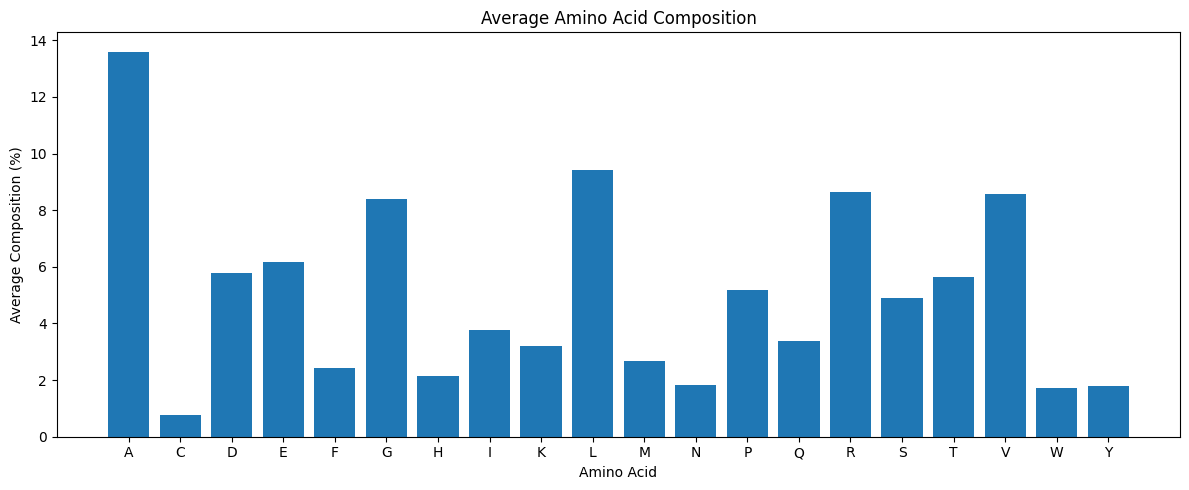

In [24]:
import matplotlib.pyplot as plt

aa_cols = [c for c in aa_df.columns if c.startswith("pct_")]

mean_comp = aa_df[aa_cols].mean()

plt.figure(figsize=(12,5))

plt.bar(mean_comp.index.str.replace("pct_",""), mean_comp.values)

plt.xlabel("Amino Acid")

plt.ylabel("Average Composition (%)")

plt.title("Average Amino Acid Composition")

plt.tight_layout()

plt.show()

### Optional B — Dipeptide Composition (per sequence)

In [25]:
from collections import Counter

dipeptide_rows = []
for record in records:
    seq = str(record.seq).upper().replace("*", "")
    if len(seq) < 2:
        continue
    dipeptides = [seq[i:i+2] for i in range(len(seq) - 1)]
    counts = Counter(dipeptides)
    row = {"ID": record.id, "Sequence": seq}
    row.update(counts)
    dipeptide_rows.append(row)

dipeptide_df = pd.DataFrame(dipeptide_rows).fillna(0)
dipeptide_df.to_csv("Peptide_Dipeptide_Composition.csv", index=False)
dipeptide_df.head()


,ID,Sequence,MS,SQ,QN,NV,VL,LT,TV,VY,YG,GA,AD,DW,WC,CR,RD,DC,CL,LR,RT,TK,KR,RQ,QL,LD,DE,EL,LG,GV,VA,AY,YD,DY,YV,VD,DL,LV,DP,PA,AQ,QA,DA,AA,AE,ER,RI,IS,SG,GR,RK,KN,NI,IP,PV,VV,VF,FP,PD,DG,GD,DH,HQ,QV,VE,EP,PT,TN,NE,EE,ET,TA,AK,KL,AL,GL,LI,MA,KA,KP,PK,KS,SN,NP,PL,LK,KI,IT,TE,EI,YK,KD,DV,LL,KF,FI,SD,DR,RG,GK,IR,RA,AR,RR,RV,VT,TG,VQ,QE,EQ,QR,IA,AV,VK,NA,RE,EV,LP,PY,YA,AG,EK,KK,KT,NG,AP,PM,MG,GP,PG,GT,TS,SS,SI,IK,PE,YE,EA,EG,AS,SE,AN,SA,GG,GE,GS,SY,ED,WT,TR,LA,DI,IE,RS,ST,TM,MT,RN,NH,VN,NF,FA,NY,LS,SK,KE,EH,HA,EF,FL,YM,MK,KG,PP,PS,SP,KV,QI,KW,WA,EN,GY,VS,SR,RL,LH,HR,YR,TD,VP,PF,FE,LE,PN,GQ,QP,VR,DD,PQ,QH,HW,DS,SL,ES,AM,MH,HI,QD,IL,MP,PI,II,IV,VM,QG,AI,IN,PR,GF,FT,FS,RF,EM,ML,VI,RP,AT,TT,TP,AH,RY,FY,YT,GH,TL,LC,GW,WK,TC,RH,HC,CA,HP,SV,RM,MF,WD,FR,WY,HD,HV,WL,LF,VW,DF,IG,SF,FW,VG,GM,FG,AC,CV,YL,DM,LQ,ME,NL,DT,TW,WR,FQ,EW,TQ,QQ,GI,MD,QY,YQ,ND,LW,QW,AF,SM,DQ,HL,SH,QF,FK,GC,QT,SW,CM,MR,YP,QM,SC,RW,NR,QS,KQ,EY,TH,HE,HK,KH,HH,HT,LM,QK,HG,EC,LY,CP,RC,CC,CQ,TI,IM,WG,LN,IW,WS,FF,WW,WV,KY,FH,PW,MM,AW,WM,MY,TF,FD,VH,YH,MI,DN,IH,IF,FN,NS,GN,NT,TY,WQ,DK,YS,MV,IQ,NQ,CF,IY,YC,CS,CE,MQ,YI,FV,NN,WI,VC,WE,HY,IC,PC,CN,FC,CI,CK,CG,CD,KC,KM,HS,YY,CH,MN,YW,PH,WP,WF,CT,YN,CY,HM,YF,NK,HF,WN,MW,NM,MC,CW,QC,FM,WH,NW,HN
0,Pep_1,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

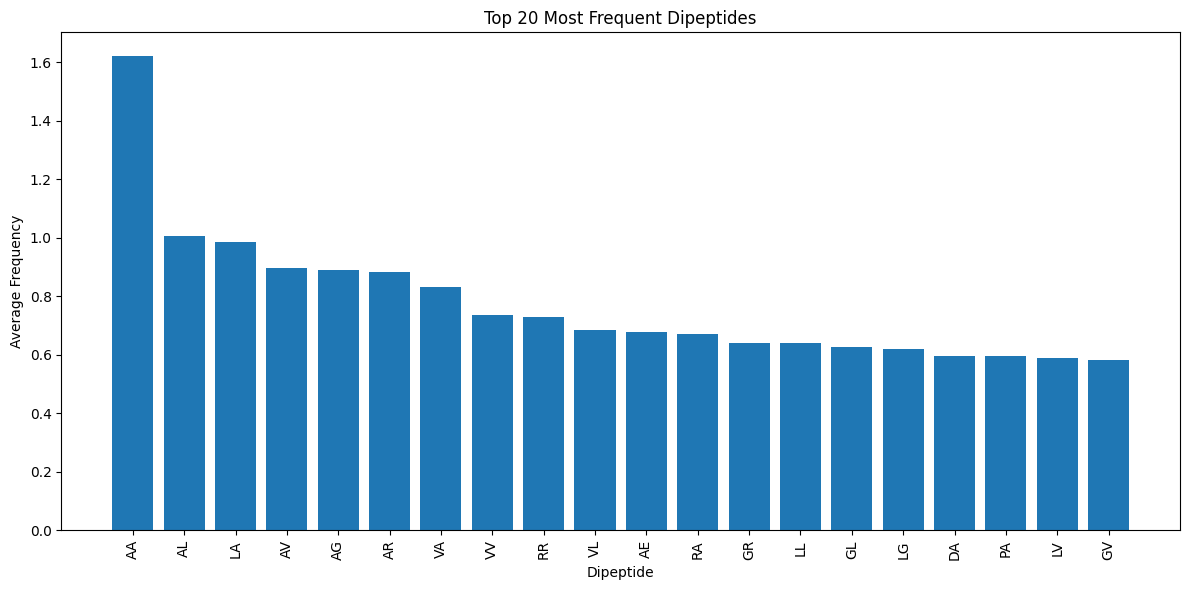

In [26]:
import matplotlib.pyplot as plt

# Remove metadata columns
feature_cols = [c for c in dipeptide_df.columns if c not in ["ID", "Sequence"]]

# Mean occurrence of each dipeptide
mean_counts = dipeptide_df[feature_cols].mean()

# Top 20
top20 = mean_counts.sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))

plt.bar(top20.index, top20.values)

plt.xticks(rotation=90)

plt.xlabel("Dipeptide")

plt.ylabel("Average Frequency")

plt.title("Top 20 Most Frequent Dipeptides")

plt.tight_layout()

plt.show()

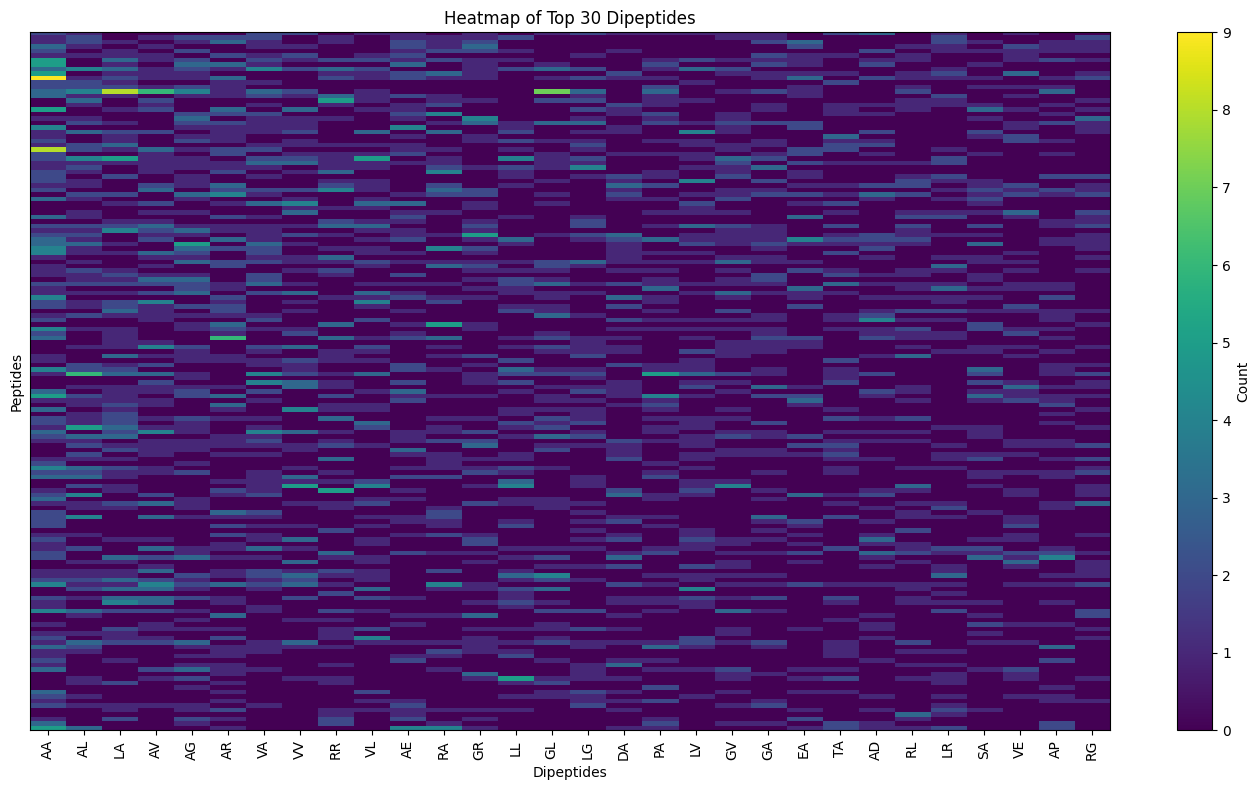

In [27]:
import matplotlib.pyplot as plt

top30 = mean_counts.sort_values(ascending=False).head(30).index

plt.figure(figsize=(14,8))

plt.imshow(dipeptide_df[top30], aspect='auto')

plt.colorbar(label="Count")

plt.xticks(
    range(len(top30)),
    top30,
    rotation=90
)

plt.yticks([])

plt.xlabel("Dipeptides")

plt.ylabel("Peptides")

plt.title("Heatmap of Top 30 Dipeptides")

plt.tight_layout()

plt.show()

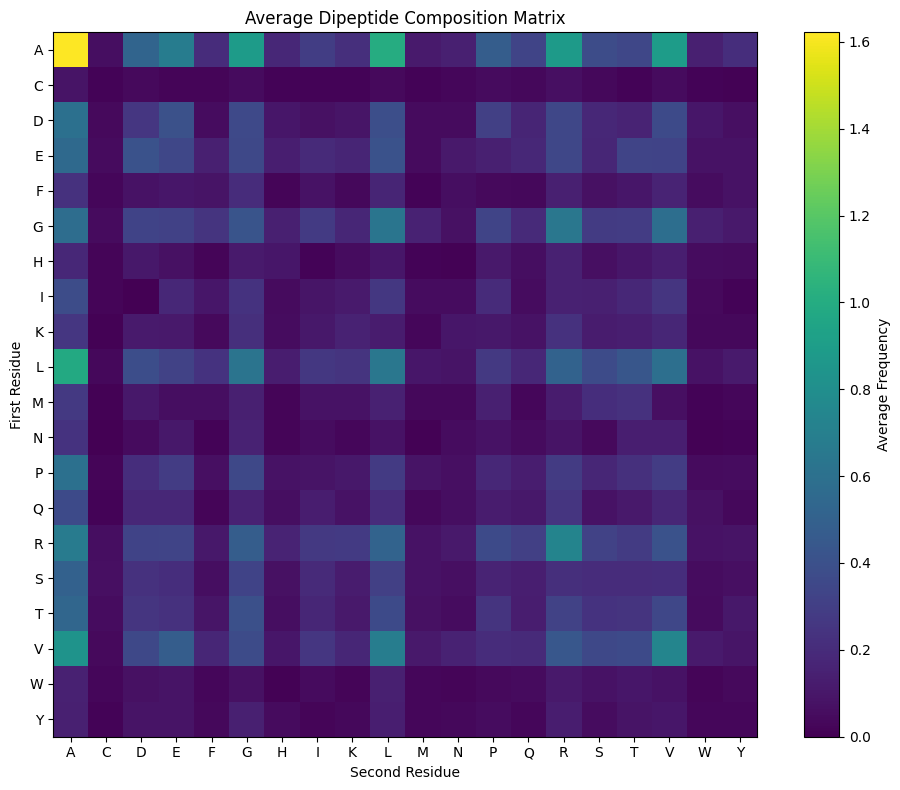

In [28]:
import numpy as np
import matplotlib.pyplot as plt

AA = "ACDEFGHIKLMNPQRSTVWY"

matrix = np.zeros((20,20))

for i,a1 in enumerate(AA):
    for j,a2 in enumerate(AA):

        dp = a1+a2

        if dp in mean_counts:
            matrix[i,j] = mean_counts[dp]

plt.figure(figsize=(10,8))

plt.imshow(matrix)

plt.colorbar(label="Average Frequency")

plt.xticks(range(20), list(AA))

plt.yticks(range(20), list(AA))

plt.xlabel("Second Residue")

plt.ylabel("First Residue")

plt.title("Average Dipeptide Composition Matrix")

plt.tight_layout()

plt.show()

### Optional C — Net Charge vs. pH (plot per sequence)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ph_range = np.arange(2, 12.5, 0.5)

plt.figure(figsize=(8, 5))
for record in records:
    seq = str(record.seq).upper().replace("*", "")
    if len(seq) == 0:
        continue
    pep = peptides.Peptide(seq)
    charges = [pep.charge(pH=p) for p in ph_range]
    plt.plot(ph_range, charges, marker="o", markersize=3, label=record.id)

plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.xlabel("pH")
plt.ylabel("Net Charge")
plt.title("Net Charge vs. pH")
if len(records) <= 15:
    plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("Charge_vs_pH.png", dpi=150)
plt.show()


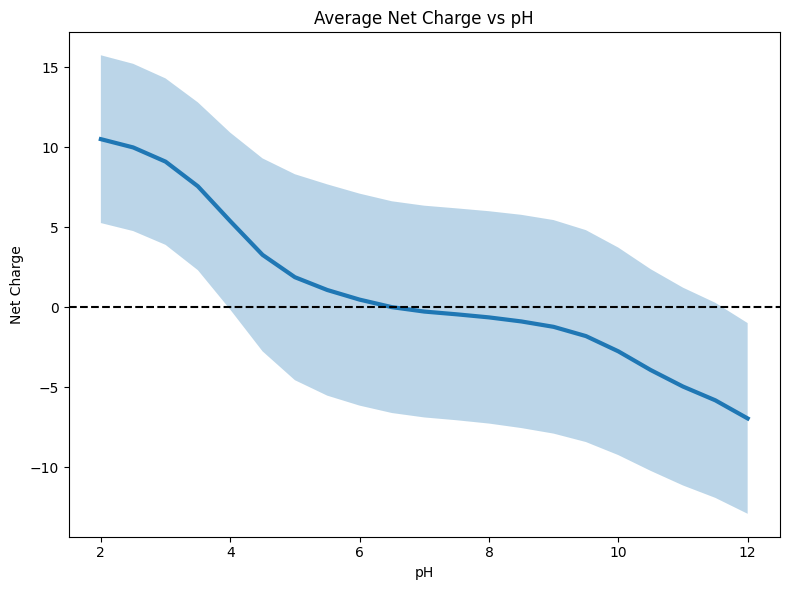

In [29]:
import numpy as np
import matplotlib.pyplot as plt

ph_range = np.arange(2, 12.5, 0.5)

charge_matrix = []

for record in records:

    seq = str(record.seq).replace("*","").upper()

    if len(seq)==0:
        continue

    pep = peptides.Peptide(seq)

    charge_matrix.append(
        [pep.charge(pH=p) for p in ph_range]
    )

charge_matrix = np.array(charge_matrix)

mean_charge = charge_matrix.mean(axis=0)
std_charge  = charge_matrix.std(axis=0)

plt.figure(figsize=(8,6))

plt.plot(ph_range, mean_charge, linewidth=3)

plt.fill_between(
    ph_range,
    mean_charge-std_charge,
    mean_charge+std_charge,
    alpha=0.3
)

plt.axhline(0,color='black',ls='--')

plt.xlabel("pH")

plt.ylabel("Net Charge")

plt.title("Average Net Charge vs pH")

plt.tight_layout()

plt.show()